## Group members:
- Adiya Sapargali (ID - 33486A)
- Ayagoz Shayakhmetova (ID- 29448A)
- Linh Chi Hoang (ID - 33141A)
- Zhanat Nurlayeva (ID - 30664A)

## Use case 1 "Marketing Attribution Model"

Necessary libraries for data analysis (pandas), visualization (matplotlib, seaborn), and date handling (datetime) and dataset are loaded. The first few rows of the data and the total number of rows are displayed to understand the structure.

In [142]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta
from collections import defaultdict
import seaborn as sns

df_1 = pd.read_csv('/Users/apple/Desktop/Advanced analytics/marketing_attribution.csv')
df_1.head()

/var/folders/wf/70l98_p931j_0zty1zh40ndc0000gn/T/ipykernel_899/998687108.py:7: DtypeWarning:

Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.



,fullVisitorId,date,visitId,visitStartTime,channelGrouping,utm_source,utm_medium,transactionRevenue,transactionId
0,9416183380303809617,2016-12-17,1481990278,1481990278,Organic Search,ask,organic,NaN,NaN
1,342964634359205532,2016-12-17,1481999067,1481999067,Organic Search,ask,organic,NaN,NaN
2,294887852901730140,2016-12-17,1481997033,1481997033,Organic Search,ask,organic,NaN,NaN
3,2904105592463883270,2016-12-17,1482038661,1482038661,Display,dfa,cpm,NaN,NaN
4,8140805711484568839,2016-12-17,1482030051,1482030051,Display,dfa,cpm,NaN,NaN


Total number of rows and amount of columns with missing values are determined.

In [72]:
len(df_1)

903653

In [73]:
df_1.isnull().sum()

fullVisitorId              0
date                       0
visitId                    0
visitStartTime             0
channelGrouping            0
utm_source                 0
utm_medium                 0
transactionRevenue    892138
transactionId         892101
dtype: int64

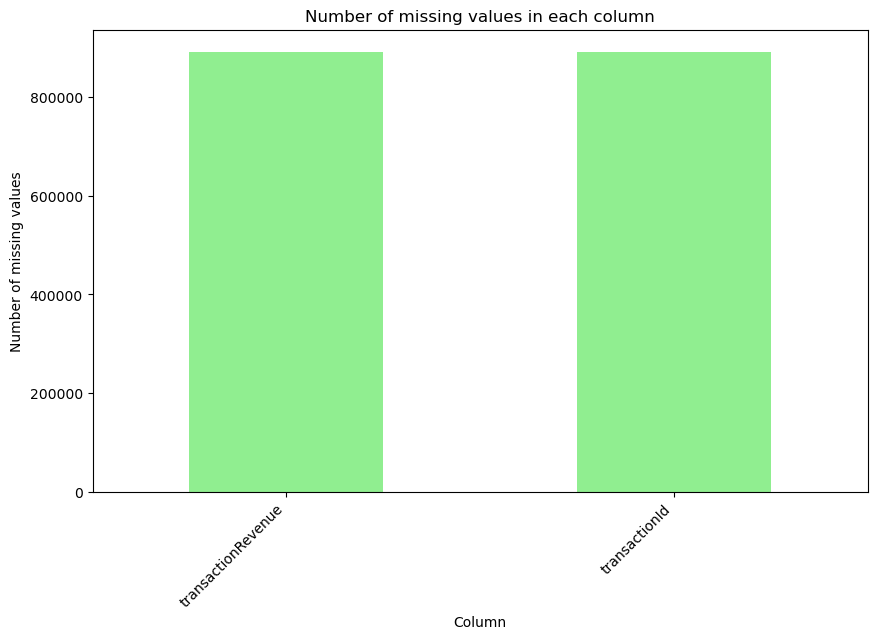

In [143]:
missing_values_1 = df_1.isnull().sum()
missing_values_1 = missing_values_1[missing_values_1 > 0]

plt.figure(figsize=(10, 6))
missing_values_1.plot(kind='bar', color='lightgreen')
plt.title('Number of missing values in each column')
plt.xlabel('Column')
plt.ylabel('Number of missing values')
plt.xticks(rotation=45, ha='right')
plt.show()

Data cleaning process has been carried out. Rows with missing 'transactionId' value are dropped since these are not useful for conversion analysis.

In [74]:
df_1 = df_1.dropna(subset=['transactionId'])

The 'date' column is converted to datetime format to facilitate date-based operations. To understand date range maximum and minimum dates in dataset are defined.

In [75]:
df_1['date'] = pd.to_datetime(df_1['date'])

print(f"Minimum date in the dataset: {df_1['date'].min()}")
print(f"Maximum date in the dataset: {df_1['date'].max()}")

Minimum date in the dataset: 2016-08-01 00:00:00
Maximum date in the dataset: 2017-08-01 00:00:00


Attribution window is set as last 30 days. The data is filtered to include only the last 30 days, based on the maximum date in the dataset.

In [76]:
max_date = df_1['date'].max()
attribution_window = 30
df_1 = df_1[df_1['date'] >= (max_date - timedelta(days=attribution_window))]

In [77]:
print(f"Number of rows after filtering: {len(df_1)}", "\n")
print(df_1.head())

Number of rows after filtering: 1071 

              fullVisitorId       date     visitId  visitStartTime  \
623948  3694234028523165868 2017-07-02  1499026072      1499026072   
624262  8197879643797712877 2017-07-02  1498996476      1498996476   
624333  9460311742865907976 2017-07-02  1499012816      1499012816   
624424  3117858606721790013 2017-07-02  1499002322      1499002322   
624585  5569275433551045400 2017-07-02  1499007891      1499007891   

       channelGrouping utm_source utm_medium  transactionRevenue  \
623948         Display        dfa        cpm               21.19   
624262  Organic Search     google    organic              382.94   
624333     Paid Search     google        cpc               37.48   
624424  Organic Search     google    organic               52.56   
624585  Organic Search     google    organic               67.97   

                          transactionId  
623948  ORD201707021442,ORD201707021442  
624262  ORD201707021563,ORD201707021563  
62433

The number of interactions for each channel is counted and plotted using a bar chart.

In [78]:
interaction_counts = df_1['channelGrouping'].value_counts()
print(interaction_counts)

channelGrouping
Referral          553
Organic Search    311
Direct            130
Paid Search        51
Display            20
Affiliates          4
Social              2
Name: count, dtype: int64


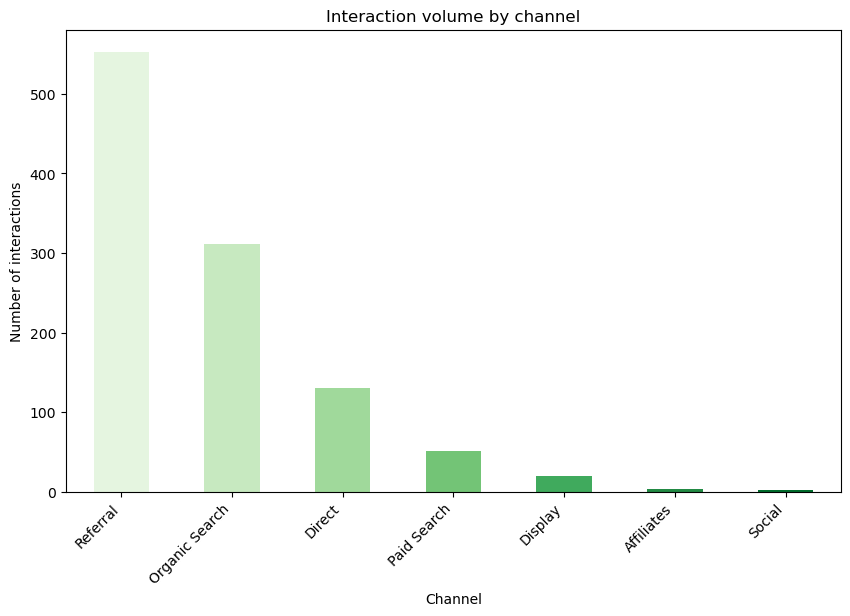

In [79]:
interaction_counts.plot(kind='bar', figsize=(10, 6), color=sns.color_palette("Greens", len(interaction_counts)))
plt.title('Interaction volume by channel')
plt.xlabel('Channel')
plt.ylabel('Number of interactions')
plt.xticks(rotation=45, ha='right')
plt.show()

The last interaction for each user session is identified. Transactions attributed to the last click channel are counted and printed.

In [80]:
df_1['last_click_channel'] = df_1.sort_values('date').groupby('fullVisitorId')['channelGrouping'].transform('last')

last_click_conversions = df_1[df_1['transactionId'].notnull()].groupby('last_click_channel')['transactionId'].count()
print("Last-click Model Attribution:\n", last_click_conversions)

Last-click Model Attribution:
 last_click_channel
Affiliates          4
Direct            130
Display            20
Organic Search    312
Paid Search        50
Referral          553
Social              2
Name: transactionId, dtype: int64


Functions are defined to create a transition matrix and calculate Markov chain attributions. Paths of user interactions are prepared and used to create a transition matrix. Markov chain attributions are calculated based on the transition matrix and scaled to match the total number of last click conversions. In this model 'transactionId' is used as a boolean to directly indicate whether a transaction occurred. If a 'transactionId' is present, it means a conversion happened, and if it's absent, no conversion occurred.

In [81]:
def get_transition_matrix(paths):
    transition_counts = defaultdict(lambda: defaultdict(int))
    for path in paths:
        for i in range(len(path) - 1):
            transition_counts[path[i]][path[i + 1]] += 1
    transition_matrix = {k: {kk: v / sum(vv.values()) for kk, v in vv.items()} for k, vv in transition_counts.items()}
    return transition_matrix

def get_markov_attribution(transition_matrix, paths):
    channel_attribution = defaultdict(float)
    for path in paths:
        for i in range(len(path) - 1):
            channel_attribution[path[i]] += transition_matrix[path[i]].get(path[i + 1], 0)
    total_attribution = sum(channel_attribution.values())
    return {k: v / total_attribution for k, v in channel_attribution.items()}

paths = df_1.groupby('fullVisitorId')['channelGrouping'].apply(list).tolist()

transition_matrix = get_transition_matrix(paths)
attributions = get_markov_attribution(transition_matrix, paths)

print("Markov Chain Attribution:\n", attributions)

Markov Chain Attribution:
 {'Referral': 0.6530612244897959, 'Organic Search': 0.24489795918367346, 'Paid Search': 0.02040816326530612, 'Direct': 0.08163265306122448}


The results of Markov and Last Click attributions are converted to DataFrames and merged for comparison. The merged DataFrame is displayed.

In [82]:
total_conversions_last_click = last_click_conversions.sum()
markov_scaled = {k: v * total_conversions_last_click for k, v in attributions.items()}

markov_df_1 = pd.DataFrame.from_dict(markov_scaled, orient='index', columns=['Markov Chain Model']).reset_index()
markov_df_1.rename(columns={'index': 'Channel'}, inplace=True)

last_click_df_1 = last_click_conversions.reset_index()
last_click_df_1.rename(columns={'transactionId': 'Last-click Model', 'last_click_channel': 'Channel'}, inplace=True)

comparison_df_1 = markov_df_1.merge(last_click_df_1, on='Channel', how='outer')
comparison_df_1.fillna(0, inplace=True)

In [83]:
comparison_df_1

,Channel,Markov Chain Model,Last-click Model
0,Referral,699.428571,553
1,Organic Search,262.285714,312
2,Paid Search,21.857143,50
3,Direct,87.428571,130
4,Affiliates,0.000000,4
5,Display,0.000000,20
6,Social,0.000000,2


The comparison of attribution models is visualized using bar charts and heatmaps.

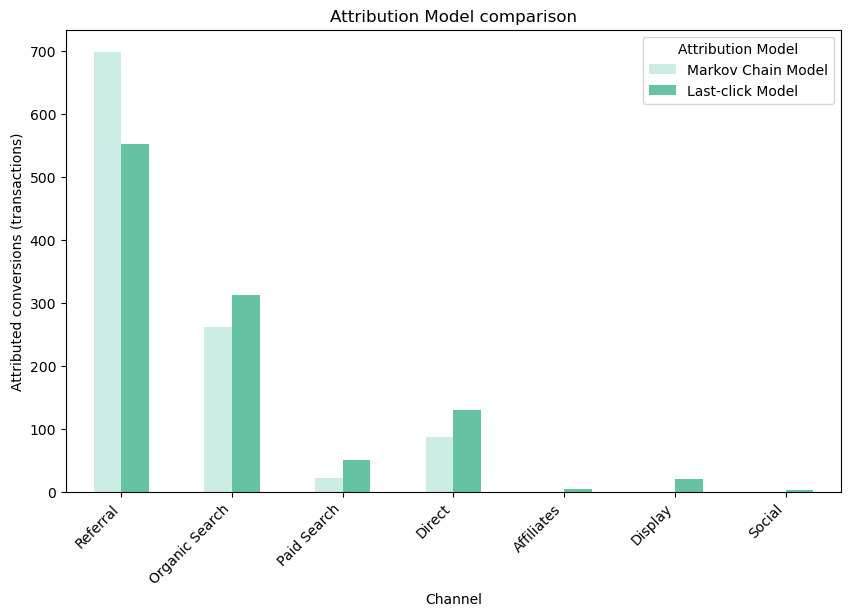

In [84]:
ax = comparison_df_1.set_index('Channel').plot(kind='bar', figsize=(10, 6), color=sns.color_palette("BuGn", len(comparison_df_1.columns)))
plt.title('Attribution Model comparison')
plt.xlabel('Channel')
plt.ylabel('Attributed conversions (transactions)')
plt.legend(title='Attribution Model')
plt.xticks(rotation=45, ha='right')
plt.show()

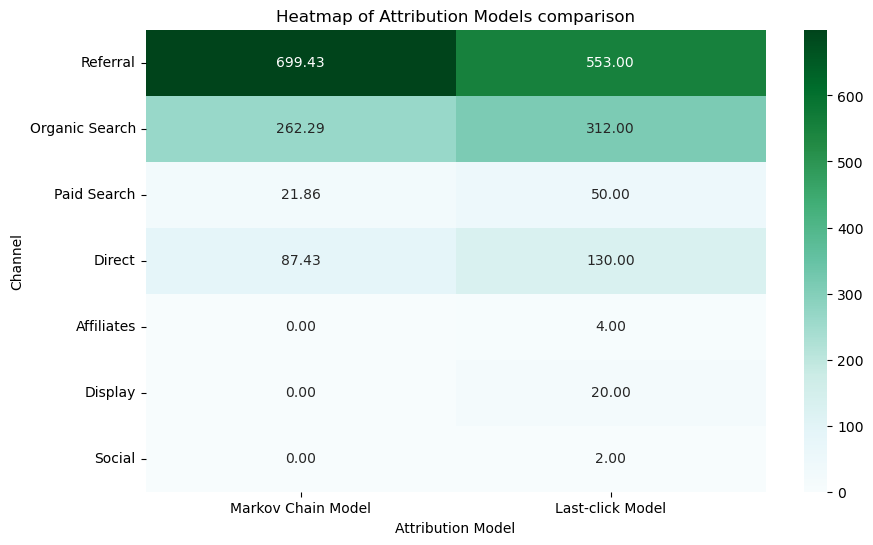

In [85]:
plt.figure(figsize=(10, 6))
sns.heatmap(comparison_df_1.set_index('Channel'), annot=True, cmap='BuGn', fmt=".2f")
plt.title('Heatmap of Attribution Models comparison')
plt.xlabel('Attribution Model')
plt.ylabel('Channel')
plt.show()

## Use case 2 "Customer Segmentation"

### Loading necessary libraries (pandas, matplotlib)

In [86]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import plotly.express as px

### Loading and sorting the original dataset

In [87]:
df_2 = pd.read_csv('/Users/apple/Desktop/Advanced analytics/orders.csv')

In [88]:
# Change the format of the column "date"
df_2['date'] = pd.to_datetime(df_2['date'], format='%Y%m%d')

In [89]:
# Sort the dataset in descending order by date
df_2= df_2.sort_values(by='date', ascending=False)
# Remove duplicate invoices
df_2 = df_2.drop_duplicates(subset='InvoiceId')
df_2.head(10)

,date,CustomerId,country,InvoiceId,SKU,productPrice,productQuantity
1286734,2022-03-17,0xcPZa4/LE/mLcwh3sY8qQ==,Italy,Y58OjBdWFko4aOS/w2rWJg==,kX00C83/MbxwSUrAhl5G3w==,10.19,1
3575015,2022-03-17,5Zthk91X4guopgu26Bcn6g==,Mozambique,PpPvi9JOncaly6dFlUOpDw==,U/EJb58YXdxQqk19XxtSXA==,23.97,12
270794,2022-03-17,CcX6OhTiLaIgELqd1z+0Kw==,France,F03IrXut+S11SaaTPVwd9A==,Lfjws/JhrpyRoHlYRUMxtg==,20.97,2
742856,2022-03-17,so4jpRsAZKQx34MZOxChDw==,France,23mNfmBU+z1N1JmldraEgA==,gkh0RAUtlD0VaIUHDHGg0w==,5.99,1
3301761,2022-03-17,UHrST3r/07A4Fx+EmBGVMA==,France,rPn3NCeownJ2uEWusYahuQ==,we5PrOnsGbAH2YbAmtNMbQ==,17.97,2
1854281,2022-03-17,r7yhZArVnx2UsjtVBosXmA==,Italy,i6jmAjnvu8PWVNtdFfa/mA==,CcMJ2gRS7yCd551qKY7LUg==,14.98,1
388539,2022-03-17,IXYfginqnJzoWQwJSAjjNQ==,France,0jbXhCL4cqvyKyJEb1PuNw==,/ZbUMwpxtog/UB5FmESKFA==,5.24,1
3958513,2022-03-17,lEn3YiqhoN5zlWj4lFegyQ==,Italy,7gM7zzhELTOaf2MoXnp1JA==,CcMJ2gRS7yCd551qKY7LUg==,29.97,2
3388584,2022-03-17,XjFYzxqkz+CxF0WLz4Ooig==,Spain,z1FOIxPyAx0rY+4A9BhE/A==,d5YvsykEq4HMp6NezWNS+w==,29.97,2
617493,2022-03-17,LI3wDmo8lWROZs4O/NThRw==,Austria,acBMAyVu91FgPfZ+KdU8bg==,cc0Q1y0uyEzxaDC9eAtt4w==,3.15,1


In [90]:
# Count the number of orders by country
df_2.country.value_counts()

country
France                   240777
Italy                    226870
Spain                     73389
Ukraine                   58396
United Kingdom            38700
                          ...  
St. Pierre & Miquelon         1
Sierra Leone                  1
Anguilla                      1
Myanmar (Burma)               1
South Sudan                   1
Name: count, Length: 197, dtype: int64

In [91]:
# Check the type of the columns
df_2.dtypes

date               datetime64[ns]
CustomerId                 object
country                    object
InvoiceId                  object
SKU                        object
productPrice              float64
productQuantity             int64
dtype: object

### RFM Calculation (RFM stands for Recency, Frequency, Monetary)

#### Recency

In [92]:
# Define the reference day (the last date recorded in the original dataset is "2022-17-03")
day = pd.to_datetime('2022-04-01')

# Calculate Recency value (The number of days after customers' latest order)
recency = df_2.groupby('CustomerId').agg(
    recency_days=pd.NamedAgg(column='date', aggfunc=lambda x: (day - x.max()).days)
)
recency

,recency_days
CustomerId,
+++SJgx/2IJ+dXq7vF8COg==,124
+++aKiAiXhTfaqCLC/kyWA==,381
++/G67YHZTMKdpvANeYPLw==,442
++/GTDXvJzF11ZIUz81SPg==,217
++0Dxza60/nPDbfORBYuuA==,34
...,...
zzyyHmcBdlPu2LT05kFnrQ==,247
zzz2aWARN6OJELfdgOZpWw==,50
zzzCCNCA1718e2kRryHpJQ==,380


#### Frequency

In [93]:
# Calculate frequency of invoices per customer
freq = df_2.groupby(["CustomerId"])[["InvoiceId"]].count()

freq

,InvoiceId
CustomerId,
+++SJgx/2IJ+dXq7vF8COg==,1
+++aKiAiXhTfaqCLC/kyWA==,1
++/G67YHZTMKdpvANeYPLw==,1
++/GTDXvJzF11ZIUz81SPg==,1
++0Dxza60/nPDbfORBYuuA==,1
...,...
zzyyHmcBdlPu2LT05kFnrQ==,1
zzz2aWARN6OJELfdgOZpWw==,1
zzzCCNCA1718e2kRryHpJQ==,1


#### Monetary

In [94]:
# The value of each order can be calculated by looking at the production of "productPrice" and "productQuantity"
df_2["total"]=df_2["productPrice"]*df_2["productQuantity"]

# Find the total money payed by each customer
money=df_2.groupby(["CustomerId"])[["total"]].sum()

money

,total
CustomerId,
+++SJgx/2IJ+dXq7vF8COg==,107.85
+++aKiAiXhTfaqCLC/kyWA==,11.98
++/G67YHZTMKdpvANeYPLw==,33.54
++/GTDXvJzF11ZIUz81SPg==,41.94
++0Dxza60/nPDbfORBYuuA==,53.88
...,...
zzyyHmcBdlPu2LT05kFnrQ==,60.00
zzz2aWARN6OJELfdgOZpWw==,143.76
zzzCCNCA1718e2kRryHpJQ==,23.94


In [95]:
# Change the name of each column of each dataset
recency.columns=["Recency"]
freq.columns=["Frequency"]
money.columns=["Monetary"]

In [96]:
# Put all three dataset into one merged dataset 
RFM=pd.concat([recency,freq,money], axis=1)
RFM

,Recency,Frequency,Monetary
CustomerId,,,
+++SJgx/2IJ+dXq7vF8COg==,124,1,107.85
+++aKiAiXhTfaqCLC/kyWA==,381,1,11.98
++/G67YHZTMKdpvANeYPLw==,442,1,33.54
++/GTDXvJzF11ZIUz81SPg==,217,1,41.94
++0Dxza60/nPDbfORBYuuA==,34,1,53.88
...,...,...,...
zzyyHmcBdlPu2LT05kFnrQ==,247,1,60.00
zzz2aWARN6OJELfdgOZpWw==,50,1,143.76
zzzCCNCA1718e2kRryHpJQ==,380,1,23.94


### Find optimal number of clusters using Elbow method

/Users/apple/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/Users/apple/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/Users/apple/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/Users/apple/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/Users/apple/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.

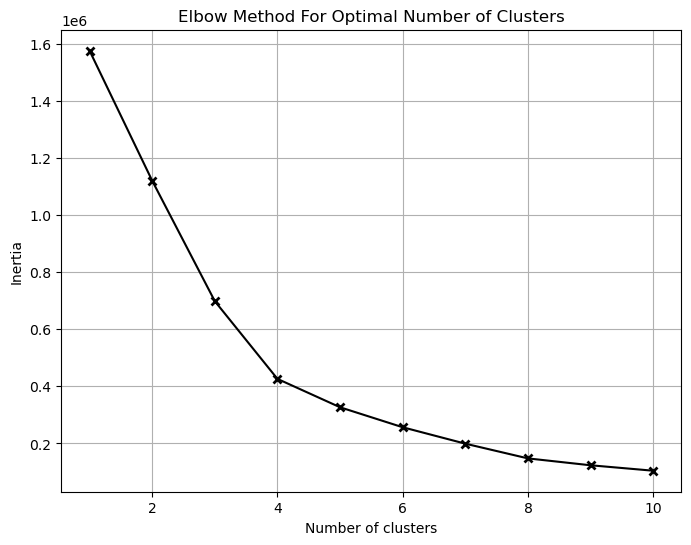

In [97]:
# Select features for clustering
features = RFM[['Frequency', 'Recency', 'Monetary']]

# Scale the dataset
scaler = StandardScaler()
scaled = scaler.fit_transform(features)

# Elbow method to find the optimal number of clusters
inertia = []
range_n_clusters = range(1, 11)

for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=0).fit(scaled)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 6), facecolor='white')  # Set the background color to white
plt.plot(range_n_clusters, inertia, marker='x', linestyle='-', color='black', markerfacecolor='white', markeredgewidth=2, markeredgecolor='black')
plt.xlabel('Number of clusters', color='black')  # Set the color of x-axis label to black
plt.ylabel('Inertia', color='black')  # Set the color of y-axis label to black
plt.title('Elbow Method For Optimal Number of Clusters', color='black')  # Set the color of title to black
plt.grid(True)  # Add gridlines
plt.show()


### Clustering customers using Kmeans

In [98]:
# Accoring to the Elbow method, the optimal number of clusters is 4
kmeans=KMeans(n_clusters=4)
kmeans.fit(scaled)
# Add the column "Clusters" with assigned cluster for each customer
RFM["Clusters"]=(kmeans.labels_)
RFM

/Users/apple/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



,Recency,Frequency,Monetary,Clusters
CustomerId,,,,
+++SJgx/2IJ+dXq7vF8COg==,124,1,107.85,1
+++aKiAiXhTfaqCLC/kyWA==,381,1,11.98,0
++/G67YHZTMKdpvANeYPLw==,442,1,33.54,0
++/GTDXvJzF11ZIUz81SPg==,217,1,41.94,1
++0Dxza60/nPDbfORBYuuA==,34,1,53.88,1
...,...,...,...,...
zzyyHmcBdlPu2LT05kFnrQ==,247,1,60.00,0
zzz2aWARN6OJELfdgOZpWw==,50,1,143.76,1
zzzCCNCA1718e2kRryHpJQ==,380,1,23.94,0


In [99]:
# Calculate the mean of Recency, Frequency, Monetary of each cluster
group=RFM.groupby(["Clusters"])[["Recency", "Frequency", "Monetary"]].mean()
group

,Recency,Frequency,Monetary
Clusters,,,
0,354.668899,1.164542,1.703159e+02
1,106.515722,1.804270,8.841492e+02
2,123.000000,1676.000000,4.044394e+07
3,53.925926,518.333333,2.593540e+06


In [100]:
# Categorize the clusters 
def func(row):
    if row["Clusters"]==0:
        return "Quite new - Little freq - Little pay"
    elif row["Clusters"]==2:
        return "Little old - High freq - High pay"
    elif row["Clusters"]==3:
        return "New - Quite freq - Quite high pay"
    else:
        return "Old - Least frequent - Pay least"

In [101]:
RFM["Category"]=RFM.apply(func, axis=1)
RFM

,Recency,Frequency,Monetary,Clusters,Category
CustomerId,,,,,
+++SJgx/2IJ+dXq7vF8COg==,124,1,107.85,1,Old - Least frequent - Pay least
+++aKiAiXhTfaqCLC/kyWA==,381,1,11.98,0,Quite new - Little freq - Little pay
++/G67YHZTMKdpvANeYPLw==,442,1,33.54,0,Quite new - Little freq - Little pay
++/GTDXvJzF11ZIUz81SPg==,217,1,41.94,1,Old - Least frequent - Pay least
++0Dxza60/nPDbfORBYuuA==,34,1,53.88,1,Old - Least frequent - Pay least
...,...,...,...,...,...
zzyyHmcBdlPu2LT05kFnrQ==,247,1,60.00,0,Quite new - Little freq - Little pay
zzz2aWARN6OJELfdgOZpWw==,50,1,143.76,1,Old - Least frequent - Pay least
zzzCCNCA1718e2kRryHpJQ==,380,1,23.94,0,Quite new - Little freq - Little pay


In [102]:
# Count the number of customers of each category
result=RFM["Category"].value_counts()
result

Category
Old - Least frequent - Pay least        297864
Quite new - Little freq - Little pay    227450
New - Quite freq - Quite high pay           27
Little old - High freq - High pay            1
Name: count, dtype: int64

In [103]:
# Create an interactive bar chart 
fig = px.bar(result, x='count', orientation='h',
             log_x=True,  # Logarithmic scale for x-axis
             title='Counts by Condition',
             template='plotly_white')  # Set background color to white
fig.show()

### Clustering customers by divining customers into tiers

In [104]:
# Selecting only the first 3 columns of the RFM dataset
RFM2 = RFM.iloc[:, 0:3]
RFM2

,Recency,Frequency,Monetary
CustomerId,,,
+++SJgx/2IJ+dXq7vF8COg==,124,1,107.85
+++aKiAiXhTfaqCLC/kyWA==,381,1,11.98
++/G67YHZTMKdpvANeYPLw==,442,1,33.54
++/GTDXvJzF11ZIUz81SPg==,217,1,41.94
++0Dxza60/nPDbfORBYuuA==,34,1,53.88
...,...,...,...
zzyyHmcBdlPu2LT05kFnrQ==,247,1,60.00
zzz2aWARN6OJELfdgOZpWw==,50,1,143.76
zzzCCNCA1718e2kRryHpJQ==,380,1,23.94


In [105]:
# Define the quantiles based on the provided summary statistics
recency_quantiles = RFM2['Recency'].quantile([0.25, 0.5, 0.75]).tolist()
frequency_quantiles = RFM2['Frequency'].quantile([0.25, 0.5, 0.75]).tolist()
monetary_quantiles = RFM2['Monetary'].quantile([0.25, 0.5, 0.75]).tolist()

In [106]:
print(recency_quantiles)
print(frequency_quantiles)
print(monetary_quantiles)

[93.0, 184.0, 346.0]
[1.0, 1.0, 1.0]
[13.63, 41.94, 132.0]


In [107]:
# Define functions to map R, F, M to tiers based on quantiles
def recency_tier(recency):
    if recency <= recency_quantiles[0]:
        return 1
    elif recency <= recency_quantiles[1]:
        return 2
    elif recency <= recency_quantiles[2]:
        return 3
    else:
        return 4

def frequency_tier(frequency):
    if frequency <= frequency_quantiles[0]:
        return 4
    elif frequency <= frequency_quantiles[1]:
        return 3
    elif frequency <= frequency_quantiles[2]:
        return 2
    else:
        return 1

def monetary_tier(monetary):
    if monetary <= monetary_quantiles[0]:
        return 4
    elif monetary <= monetary_quantiles[1]:
        return 3
    elif monetary <= monetary_quantiles[2]:
        return 2
    else:
        return 1

In [108]:
# Apply the functions to the DataFrame
RFM2['R_Tier'] = RFM2['Recency'].apply(recency_tier)
RFM2['F_Tier'] = RFM2['Frequency'].apply(frequency_tier)
RFM2['M_Tier'] = RFM2['Monetary'].apply(monetary_tier)

In [109]:
# Define the segments of the customers
def customer_segment(row):
    if (row['R_Tier'] == 1) & (row['F_Tier'] == 1) & (row['M_Tier'] == 1):
        return 'Best Customers'
    elif (row['R_Tier'] == 1) & (row['F_Tier'] == 4) & (row['M_Tier'] == 2) | (row['M_Tier'] == 1):
        return 'High-spending New Customers'
    elif (row['R_Tier'] == 1) & (row['F_Tier'] == 1) & ((row['M_Tier'] == 3) | (row['M_Tier'] == 4)):
        return 'Lowest-Spending Active Loyal Customers'
    elif (row['R_Tier'] == 4) & ((row['F_Tier'] == 1) | (row['F_Tier'] == 2)) & ((row['M_Tier'] == 1) | (row['M_Tier'] == 2)):
        return 'Churned Best Customers'
    else:
        return 'Other'

In [110]:
# Apply the function to the RFM2 dataset
RFM2['Segment'] = RFM2.apply(customer_segment, axis=1)

In [111]:
RFM2

,Recency,Frequency,Monetary,R_Tier,F_Tier,M_Tier,Segment
CustomerId,,,,,,,
+++SJgx/2IJ+dXq7vF8COg==,124,1,107.85,2,4,2,Other
+++aKiAiXhTfaqCLC/kyWA==,381,1,11.98,4,4,4,Other
++/G67YHZTMKdpvANeYPLw==,442,1,33.54,4,4,3,Other
++/GTDXvJzF11ZIUz81SPg==,217,1,41.94,3,4,3,Other
++0Dxza60/nPDbfORBYuuA==,34,1,53.88,1,4,2,High-spending New Customers
...,...,...,...,...,...,...,...
zzyyHmcBdlPu2LT05kFnrQ==,247,1,60.00,3,4,2,Other
zzz2aWARN6OJELfdgOZpWw==,50,1,143.76,1,4,1,High-spending New Customers
zzzCCNCA1718e2kRryHpJQ==,380,1,23.94,4,4,3,Other


In [112]:
# Count the number of each segment
segment_counts = RFM2['Segment'].value_counts()
# Reset index to make 'Segment' a column
segment_counts= segment_counts.reset_index()
# Rename columns 
segment_counts.columns = ['Segment', 'Count']
segment_counts

,Segment,Count
0,Other,363399
1,High-spending New Customers,123749
2,Best Customers,25233
3,Lowest-Spending Active Loyal Customers,9773
4,Churned Best Customers,3188


In [113]:
# Create the bar chart
fig = px.bar(segment_counts, x='Segment', y='Count', orientation='v',
             title='Counts by Segment',
             template='plotly_white')  # Set background color to white

# Update layout to change the height of the plot
fig.update_layout(
    height=600  # Specify the height in pixels
)

# Show the plot
fig.show()

## Use case 3 "Churn rate Forecasting"

Neceassary libraries are loaded. Dataset's features are investigated.

In [114]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta
from collections import defaultdict
import seaborn as sns
import numpy as np
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [144]:
df_3 = pd.read_csv('/Users/apple/Desktop/Advanced analytics/browse_purchase/browse_purchase_2022_FY.csv')

/var/folders/wf/70l98_p931j_0zty1zh40ndc0000gn/T/ipykernel_899/161322524.py:1: DtypeWarning:

Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.



In [116]:
df_3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1195659 entries, 0 to 1195658
Data columns (total 31 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0   date                          1195659 non-null  object 
 1   customerId                    1195659 non-null  object 
 2   country                       1195659 non-null  object 
 3   city                          1195659 non-null  object 
 4   visitStartTime                1195659 non-null  int64  
 5   browser                       1195659 non-null  object 
 6   deviceCategory                1195659 non-null  object 
 7   visit_from_app                1195645 non-null  object 
 8   utm_medium                    1195659 non-null  object 
 9   channelGrouping               1195659 non-null  object 
 10  pageviews                     1193318 non-null  float64
 11  timeOnSite                    1036028 non-null  float64
 12  bounces                     

In [117]:
df_3.columns

Index(['date', 'customerId', 'country', 'city', 'visitStartTime', 'browser',
       'deviceCategory', 'visit_from_app', 'utm_medium', 'channelGrouping',
       'pageviews', 'timeOnSite', 'bounces', 'interaction_hits',
       'products_impressions', 'store_locator', 'add_to_wishlist',
       'contact_customercare', 'set_product_alert', 'products_added_to_cart',
       'products_removed_from_cart', 'products_refunded',
       'visit_with_add_to_cart', 'visit_with_remove_from_cart',
       'visit_with_purchase', 'visit_with_checkout',
       'visit_with_productDetailView', 'visit_with_productListView',
       'product_ids_purchased', 'product_quantity_purchased', 'tot_revenue'],
      dtype='object')

In [118]:
df_3.shape


(1195659, 31)

In [119]:
df_3.isnull().sum()


date                                  0
customerId                            0
country                               0
city                                  0
visitStartTime                        0
browser                               0
deviceCategory                        0
visit_from_app                       14
utm_medium                            0
channelGrouping                       0
pageviews                          2341
timeOnSite                       159631
bounces                         1036084
interaction_hits                      0
products_impressions                  0
store_locator                         0
add_to_wishlist                       0
contact_customercare                  0
set_product_alert                     0
products_added_to_cart                0
products_removed_from_cart            0
products_refunded                     0
visit_with_add_to_cart                0
visit_with_remove_from_cart           0
visit_with_purchase                   0


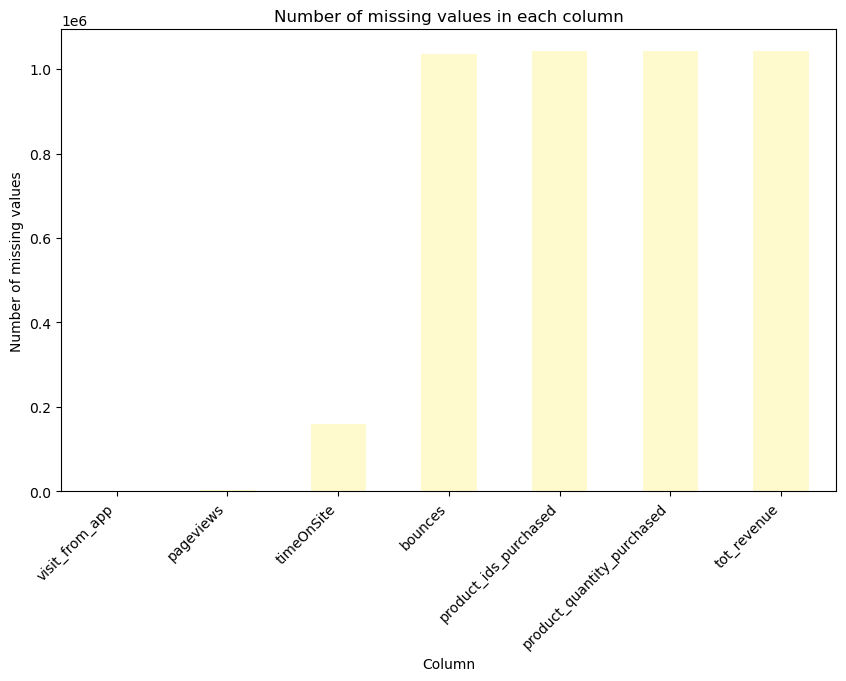

In [145]:
missing_values_3 = df_3.isnull().sum()
missing_values_3 = missing_values_3[missing_values_3 > 0]

plt.figure(figsize=(10, 6))
missing_values_3.plot(kind='bar', color='lemonchiffon')
plt.title('Number of missing values in each column')
plt.xlabel('Column')
plt.ylabel('Number of missing values')
plt.xticks(rotation=45, ha='right')
plt.show()

Data cleaning process has been carried out. Columns with more than 70% missing values are dropped since they are not critical. For the numeric columns, missing values were filled with the median. For categorical columns, missing values were filled with the mode. And then it was checked that there are no missing values in the dataset. 

In [120]:
threshold = 0.7
df_3 = df_3.loc[:, df_3.isnull().mean() < threshold]

print(df_3.columns)

numerical_cols = df_3.select_dtypes(include=['float64', 'int64']).columns
df_3[numerical_cols] = df_3[numerical_cols].fillna(df_3[numerical_cols].median())

categorical_cols = df_3.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df_3[col] = df_3[col].fillna(df_3[col].mode()[0])

print(df_3.isnull().sum())

Index(['date', 'customerId', 'country', 'city', 'visitStartTime', 'browser',
       'deviceCategory', 'visit_from_app', 'utm_medium', 'channelGrouping',
       'pageviews', 'timeOnSite', 'interaction_hits', 'products_impressions',
       'store_locator', 'add_to_wishlist', 'contact_customercare',
       'set_product_alert', 'products_added_to_cart',
       'products_removed_from_cart', 'products_refunded',
       'visit_with_add_to_cart', 'visit_with_remove_from_cart',
       'visit_with_purchase', 'visit_with_checkout',
       'visit_with_productDetailView', 'visit_with_productListView'],
      dtype='object')
date                            0
customerId                      0
country                         0
city                            0
visitStartTime                  0
browser                         0
deviceCategory                  0
visit_from_app                  0
utm_medium                      0
channelGrouping                 0
pageviews                       0
timeOnS

In [121]:
df_3.shape

(1195659, 27)

In [122]:
df_3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1195659 entries, 0 to 1195658
Data columns (total 27 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0   date                          1195659 non-null  object 
 1   customerId                    1195659 non-null  object 
 2   country                       1195659 non-null  object 
 3   city                          1195659 non-null  object 
 4   visitStartTime                1195659 non-null  int64  
 5   browser                       1195659 non-null  object 
 6   deviceCategory                1195659 non-null  object 
 7   visit_from_app                1195659 non-null  bool   
 8   utm_medium                    1195659 non-null  object 
 9   channelGrouping               1195659 non-null  object 
 10  pageviews                     1195659 non-null  float64
 11  timeOnSite                    1195659 non-null  float64
 12  interaction_hits            

In [123]:
df_3.head()

,date,customerId,country,city,visitStartTime,browser,deviceCategory,visit_from_app,utm_medium,channelGrouping,...,set_product_alert,products_added_to_cart,products_removed_from_cart,products_refunded,visit_with_add_to_cart,visit_with_remove_from_cart,visit_with_purchase,visit_with_checkout,visit_with_productDetailView,visit_with_productListView
0,2022-01-20,3UTw1Ru+ahnKAwPNAQZkxA==,France,Meudon,1642692636,Chrome,desktop,False,(none),Direct,...,0,11,0,0,1,0,1,1,1,1
1,2022-01-20,M1uzsFbXHQ+s5BIIjYcgHg==,Ukraine,Poltava,1642633226,Chrome,desktop,False,(none),Direct,...,0,14,0,0,1,0,1,1,1,0
2,2022-01-20,ZBiFJwut1IdmlSqc27edGA==,Ukraine,Mykolaiv,1642716112,Chrome,desktop,False,(none),Direct,...,0,2,0,0,1,0,1,1,1,1
3,2022-01-20,WqkjFVAdBHmwnr0j1hoFeA==,United States,Ashburn,1642639047,Safari,desktop,False,(none),Direct,...,0,16,0,0,1,0,1,1,1,1
4,2022-01-20,thZWAdudx377qV8dGAju7Q==,Algeria,(not set),1642703113,Safari,mobile,False,(none),Direct,...,0,0,0,0,0,0,1,1,0,0


The date column was converted to datetime. The date of each customer's last purchase was determined. A new column was then created to indicate whether the customer had stopped buying or not. 
And a check of the ‘churn’ column was made and shows a list of some customers with the dates of their purchases and whether they stopped buying or not. And it was also counted how many customers have stopped buying and how many are still active.

In [124]:
df_3['date'] = pd.to_datetime(df_3['date'])

max_date_3 = df_3['date'].max()
churn_cutoff_date = max_date_3 - timedelta(days=30)

last_purchase = df_3[df_3['visit_with_purchase'] > 0].groupby('customerId')['date'].max().reset_index()
last_purchase.columns = ['customerId', 'last_purchase_date']

df_3 = df_3.merge(last_purchase, on='customerId', how='left')

df_3['churn'] = df_3['last_purchase_date'].apply(lambda x: 1 if pd.isnull(x) or x < churn_cutoff_date else 0)

print(df_3[['customerId', 'date', 'churn']].drop_duplicates().head(20))
print(df_3['churn'].value_counts())

                  customerId       date  churn
0   3UTw1Ru+ahnKAwPNAQZkxA== 2022-01-20      1
1   M1uzsFbXHQ+s5BIIjYcgHg== 2022-01-20      1
2   ZBiFJwut1IdmlSqc27edGA== 2022-01-20      1
3   WqkjFVAdBHmwnr0j1hoFeA== 2022-01-20      1
4   thZWAdudx377qV8dGAju7Q== 2022-01-20      1
5   b+E5wR8JYZKvp/hdlpwLEQ== 2022-01-20      1
6   fWoECPBrH7SZDZLOEMAqcQ== 2022-01-20      1
7   JBdBEo99dXxR52OYOa7ZHQ== 2022-01-20      1
8   Ul/hUvHKInfi0ROay+XrqA== 2022-01-20      1
9   97NZUgCUHOR1BSYvmA4X5w== 2022-01-20      1
10  VYjBC7c7dTd/FfVlhy5nNg== 2022-01-20      0
11  /zMUZ9ycMfqka0RNuarRUA== 2022-01-20      1
12  Wiv2B6+u5i1w6ai174ttlw== 2022-01-20      1
13  1H0aVWeChMGbyBall7g23g== 2022-01-20      1
14  Vaeq8u+q9emz75FTtH8Wrg== 2022-01-20      1
15  e8JUKG26NZ9E/JJeCbx6vw== 2022-01-20      1
16  3yE14Y8gyqf3uhtSmht81g== 2022-01-20      1
17  Ml7IBopH3od4Jw65pCYHXg== 2022-01-20      0
18  PoWTnjA5k97c4Hh27OI1/w== 2022-01-20      1
19  RZl0VjMHyDSuzvCxpuH3jw== 2022-01-20      1
churn
1    91

In [125]:
df_3['avg_time_per_page'] = df_3['timeOnSite'] / df_3['pageviews']

df_3.replace([np.inf, -np.inf], 0, inplace=True)

print(df_3[['avg_time_per_page']].head())


   avg_time_per_page
0          44.621622
1          59.684211
2          75.000000
3          46.034483
4          37.400000


In [126]:
print(df_3.columns)

Index(['date', 'customerId', 'country', 'city', 'visitStartTime', 'browser',
       'deviceCategory', 'visit_from_app', 'utm_medium', 'channelGrouping',
       'pageviews', 'timeOnSite', 'interaction_hits', 'products_impressions',
       'store_locator', 'add_to_wishlist', 'contact_customercare',
       'set_product_alert', 'products_added_to_cart',
       'products_removed_from_cart', 'products_refunded',
       'visit_with_add_to_cart', 'visit_with_remove_from_cart',
       'visit_with_purchase', 'visit_with_checkout',
       'visit_with_productDetailView', 'visit_with_productListView',
       'last_purchase_date', 'churn', 'avg_time_per_page'],
      dtype='object')


Optimisation of data types was done.

In [127]:
df_3['pageviews'] = df_3['pageviews'].astype('float32')
df_3['timeOnSite'] = df_3['timeOnSite'].astype('float32')
df_3['interaction_hits'] = df_3['interaction_hits'].astype('int32')
df_3['products_impressions'] = df_3['products_impressions'].astype('int32')

print(df_3.dtypes)

date                            datetime64[ns]
customerId                              object
country                                 object
city                                    object
visitStartTime                           int64
browser                                 object
deviceCategory                          object
visit_from_app                            bool
utm_medium                              object
channelGrouping                         object
pageviews                              float32
timeOnSite                             float32
interaction_hits                         int32
products_impressions                     int32
store_locator                            int64
add_to_wishlist                          int64
contact_customercare                     int64
set_product_alert                        int64
products_added_to_cart                   int64
products_removed_from_cart               int64
products_refunded                        int64
visit_with_ad

The data for modeling has been prepared. The categorical variables were converted to numerical variables and the dataset was prepared for training.

In [128]:
label_encoder = LabelEncoder()
df_3['country_encoded'] = label_encoder.fit_transform(df_3['country'])
df_3['city_encoded'] = label_encoder.fit_transform(df_3['city'])
df_3['browser_encoded'] = label_encoder.fit_transform(df_3['browser'])
df_3['deviceCategory_encoded'] = label_encoder.fit_transform(df_3['deviceCategory'])
df_3['utm_medium_encoded'] = label_encoder.fit_transform(df_3['utm_medium'])
df_3['channelGrouping_encoded'] = label_encoder.fit_transform(df_3['channelGrouping'])
df_3['visit_from_app_encoded'] = label_encoder.fit_transform(df_3['visit_from_app'])

features_3 = ['pageviews', 'timeOnSite', 'interaction_hits', 
            'products_impressions', 'store_locator', 'add_to_wishlist', 
            'contact_customercare', 'set_product_alert', 'products_added_to_cart',
            'products_removed_from_cart', 'products_refunded', 'visit_with_add_to_cart',
            'visit_with_remove_from_cart', 'visit_with_purchase', 'visit_with_checkout',
            'visit_with_productDetailView', 'visit_with_productListView', 
            'country_encoded', 'city_encoded', 'browser_encoded', 
            'deviceCategory_encoded', 'utm_medium_encoded', 'channelGrouping_encoded', 
            'visit_from_app_encoded', 'avg_time_per_page']

target_3 = 'churn'

X = df_3[features_3]
y = df_3[target_3]

The data has been split into training and testing sets.

In [129]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(956527, 25) (239132, 25) (956527,) (239132,)


Model training has been done. XGBoost algorithm was used to train the churn prediction model.

In [130]:
xgb_model = xgb.XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy Score:\n", accuracy_score(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.03      0.06     57097
           1       0.77      0.99      0.87    182035

    accuracy                           0.76    239132
   macro avg       0.71      0.51      0.46    239132
weighted avg       0.74      0.76      0.67    239132

Confusion Matrix:
 [[  1776  55321]
 [   946 181089]]
Accuracy Score:
 0.7647031764882993


The classification report and confusion matrix were visualised as a histogram and heatmap.

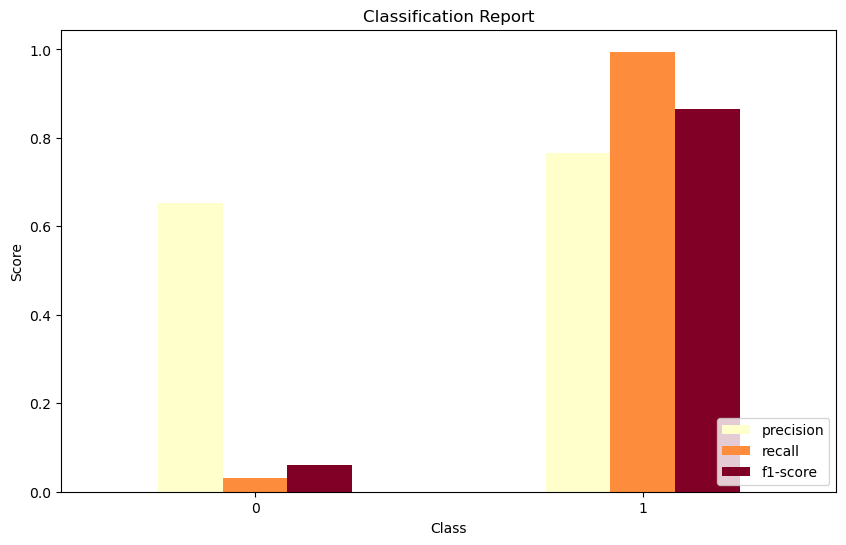

In [131]:
class_report_3 = classification_report(y_test, y_pred, output_dict=True)

report_df_3 = pd.DataFrame(class_report_3).transpose()

report_df_3[['precision', 'recall', 'f1-score']].iloc[:-3].plot(kind='bar', figsize=(10, 6), colormap='YlOrRd')
plt.title('Classification Report')
plt.xlabel('Class')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()


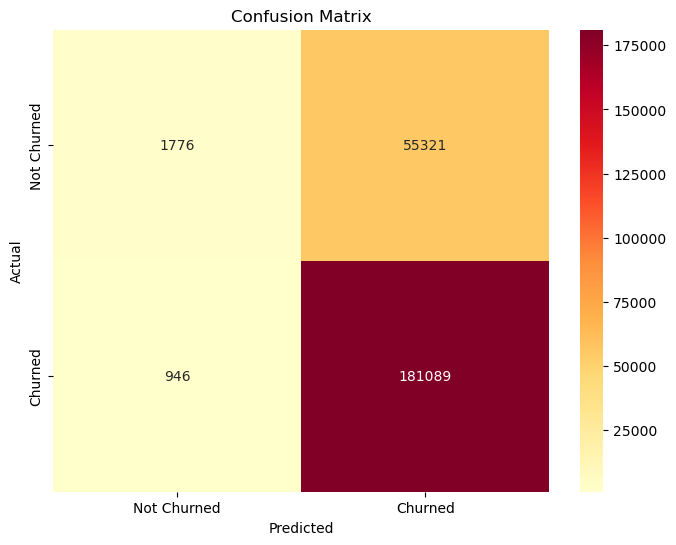

In [132]:
conf_matrix_3 = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_3, annot=True, fmt="d", cmap="YlOrRd", xticklabels=['Not Churned', 'Churned'], yticklabels=['Not Churned', 'Churned'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()


Cross-validation for XGBoost was done to check Accuracy Scores.

In [133]:
xgb_cv_scores = cross_val_score(xgb_model, X, y, cv=5, scoring='accuracy')
print(f"XGBoost Cross-Validation Accuracy Scores: {xgb_cv_scores}")
print(f"XGBoost Cross-Validation Mean Accuracy: {xgb_cv_scores.mean()}")

XGBoost Cross-Validation Accuracy Scores: [0.76544754 0.76542663 0.76467809 0.76360337 0.76418365]
XGBoost Cross-Validation Mean Accuracy: 0.764667852218564


The Customer Churn probability was calculated using XGBoost.

In [134]:
xgb_probabilities = xgb_model.predict_proba(X)[:, 1]
df_3['xgb_churn_probability'] = xgb_probabilities

In [135]:
print(df_3[['customerId', 'xgb_churn_probability']].head(10))

                 customerId  xgb_churn_probability
0  3UTw1Ru+ahnKAwPNAQZkxA==               0.479250
1  M1uzsFbXHQ+s5BIIjYcgHg==               0.683394
2  ZBiFJwut1IdmlSqc27edGA==               0.702540
3  WqkjFVAdBHmwnr0j1hoFeA==               0.442093
4  thZWAdudx377qV8dGAju7Q==               0.590825
5  b+E5wR8JYZKvp/hdlpwLEQ==               0.584708
6  fWoECPBrH7SZDZLOEMAqcQ==               0.612392
7  JBdBEo99dXxR52OYOa7ZHQ==               0.590666
8  Ul/hUvHKInfi0ROay+XrqA==               0.587755
9  97NZUgCUHOR1BSYvmA4X5w==               0.509921


In [136]:
df_3.head()

,date,customerId,country,city,visitStartTime,browser,deviceCategory,visit_from_app,utm_medium,channelGrouping,...,churn,avg_time_per_page,country_encoded,city_encoded,browser_encoded,deviceCategory_encoded,utm_medium_encoded,channelGrouping_encoded,visit_from_app_encoded,xgb_churn_probability
0,2022-01-20,3UTw1Ru+ahnKAwPNAQZkxA==,France,Meudon,1642692636,Chrome,desktop,False,(none),Direct,...,1,44.621622,59,5413,3,0,0,2,0,0.479250
1,2022-01-20,M1uzsFbXHQ+s5BIIjYcgHg==,Ukraine,Poltava,1642633226,Chrome,desktop,False,(none),Direct,...,1,59.684211,179,6588,3,0,0,2,0,0.683394
2,2022-01-20,ZBiFJwut1IdmlSqc27edGA==,Ukraine,Mykolaiv,1642716112,Chrome,desktop,False,(none),Direct,...,1,75.000000,179,5726,3,0,0,2,0,0.702540
3,2022-01-20,WqkjFVAdBHmwnr0j1hoFeA==,United States,Ashburn,1642639047,Safari,desktop,False,(none),Direct,...,1,46.034483,182,685,12,0,0,2,0,0.442093
4,2022-01-20,thZWAdudx377qV8dGAju7Q==,Algeria,(not set),1642703113,Safari,mobile,False,(none),Direct,...,1,37.400000,3,4,12,1,0,2,0,0.590825


The Churn probabilities were visualised as a histogram.

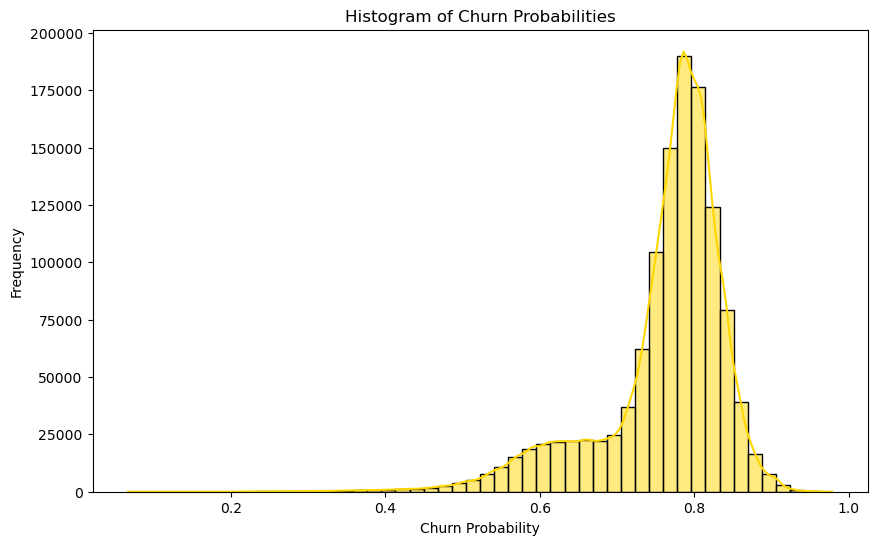

In [137]:
plt.figure(figsize=(10, 6))
sns.histplot(df_3['xgb_churn_probability'], bins=50, kde=True, color='gold')
plt.title('Histogram of Churn Probabilities')
plt.xlabel('Churn Probability')
plt.ylabel('Frequency')
plt.show()

Customers were categorised into different risk segments according to their probability of churn. Each customer's probability of churn is estimated and assigned a corresponding risk segment. The number of customers in each risk segment has also been calculated and displayed.

In [138]:
def risk_segment(probability):
    if probability >= 0.75:
        return 'High Risk'
    elif probability >= 0.50:
        return 'Medium Risk'
    elif probability >= 0.25:
        return 'Low Risk'
    else:
        return 'Very Low Risk'

df_3['risk_segment'] = df_3['xgb_churn_probability'].apply(risk_segment)

print(df_3['risk_segment'].value_counts())


risk_segment
High Risk        848485
Medium Risk      333484
Low Risk          13342
Very Low Risk       348
Name: count, dtype: int64


A graph of the risk segment distribution was plotted.

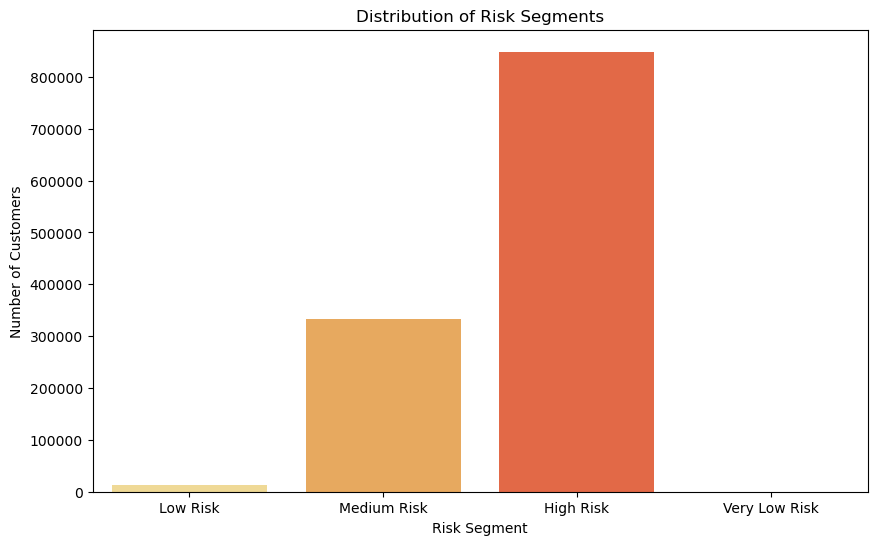

In [139]:
plt.figure(figsize=(10, 6))
sns.countplot(x='risk_segment', data=df_3, palette='YlOrRd')
plt.title('Distribution of Risk Segments')
plt.xlabel('Risk Segment')
plt.ylabel('Number of Customers')
plt.show()


The most important features for XGBoost model predictions have been identified. A histogram was created showing these features in order of importance.

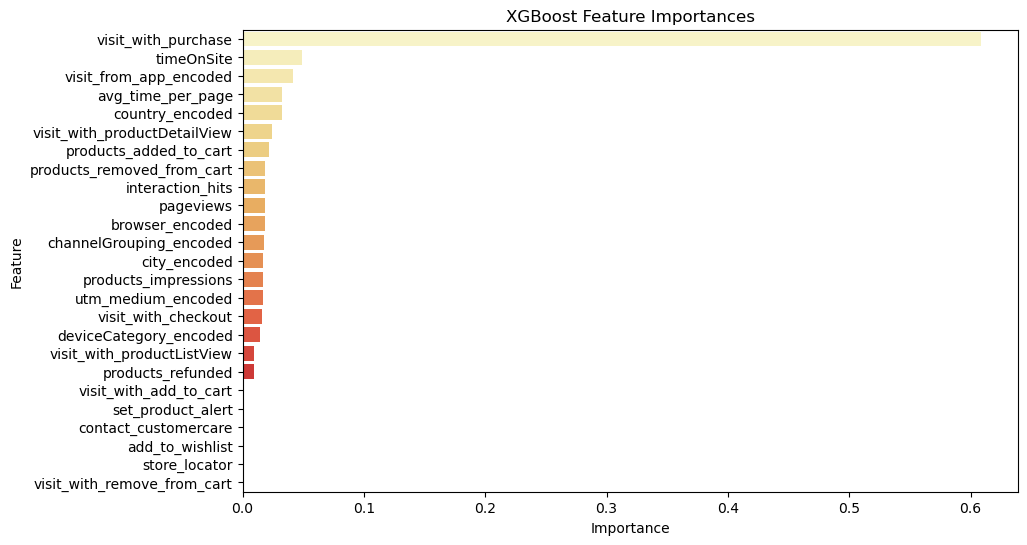

In [140]:
xgb_feature_importances = xgb_model.feature_importances_
xgb_importance_df_3 = pd.DataFrame({'Feature': X_train.columns, 'Importance': xgb_feature_importances})
xgb_importance_df_3 = xgb_importance_df_3.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=xgb_importance_df_3, palette='YlOrRd')
plt.title('XGBoost Feature Importances')
plt.show()
